In [165]:
"""

Start by finding Empiral CDF Values

"""



'\n\nStart by finding Empiral CDF Values\n\n'

In [166]:

import logging
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
# from decimal import Decimal
from datetime import datetime, timezone

import matplotlib.pyplot as plt
from scipy import stats



In [167]:
class AvailableDatasets:
    """Available Datasets, returns request ID"""

    FULL_YEAR_2024__CME_JPY_V: str = "GLBX-20251028-HAE9P7SP3U"
    FULL_YEAR_2023__CME_JPY_V: str = "GLBX-20251116-MJ5JKQA9A4"
    FULL_YEAR_2022__CME_JPY_V: str = "GLBX-20251115-DJHUGKSLWB"

    # 1 Day TBBO Data ( *TBBO* 6J.v 1 day "2022-11-10")
    TBBO__FULL_DAY_2022_11_10__CME_JPY_V: str = "GLBX-20251117-8KDC7XCEYW"

    # 1 Day TBBO Data ( *TRADES* 6J.v 1 day "2022-11-10") - MISTAKENLY BOUGHT
    TRADES__FULL_DAY_2022_11_10__CME_JPY_V: str = "GLBX-20251117-TWBJGCYALB"
    
    # Continuous Contract (Not Especially Useful)
    FULL_YEAR_2022__CME_JPY_C: str = "GLBX-20251027-AG9BYWQJ6L"

    

In [168]:

# WORKING DIRECTORY
MAIN_DIR = Path("/Users/number6/Projects/Bimini/")

# HISTORICAL DATA
HISTORICAL_DATA = MAIN_DIR / "0_data" / "historical"

# IMPORT PATH
PARQUET_DIR = HISTORICAL_DATA / "parquet"

# EXPORT PATH
EXPORT_DIR = MAIN_DIR / "journal_results"


In [169]:


"""

?

"""



TICK_SIZE = 0.00001




# Convert START_DATE and END_DATE to nanosecond epochs (integers)
START_DATE_NS = int(
    datetime(
        year=2022,
        month=11,
        day=10,
        hour=14,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)

END_DATE_NS = int(
    datetime(
        year=2022,
        month=11,
        day=10,
        hour=18,
        minute=0,
        second=0,
        tzinfo=timezone.utc,
    ).timestamp() * 1e9
)


hrf_start_dt = datetime.fromtimestamp(START_DATE_NS / 1e9, tz=timezone.utc)
hrf_end_dt = datetime.fromtimestamp(END_DATE_NS / 1e9, tz=timezone.utc)

print("START_DATE_NS", hrf_start_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("END_DATE_NS", hrf_end_dt.strftime("%Y-%m-%d %H:%M:%S %Z"))



START_DATE_NS 2022-11-10 14:00:00 UTC
END_DATE_NS 2022-11-10 18:00:00 UTC


In [170]:


# ============================================================================
# [START] - Import Filters
# ============================================================================



# # Data files to glob for processing
# DATA_GLOB = pl.scan_parquet(str(PARQUET_DIR / request_id / "*.parquet"))

# Method 2: List of glob patterns for MULTIPLE DIRECTORIES
DATA_GLOB = pl.scan_parquet([
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2022__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2023__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2024__CME_JPY_V / "*.parquet"),
])


# [ ACTUAL FILTER REQUEST FOR PROCESSING ]
lf = (

    # 0) Glob across all files in data directory
    DATA_GLOB
    
    # 1) Select only needed columns FIRST (reduces data volume)
    .select([
        "ts_recv",
        "price",
        "size",
        "side",
        "sequence",
        "instrument_id",
    ])

    # 2.) Convert to physical int representation (just stripping data, saved as int64 in Parquet file)
    .with_columns(
        pl.col("ts_recv").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("ts_recv"),
        pl.col("side").cast(pl.Categorical)
    )
    
    # 3) Filter on raw uint64 epoch values (fastest)
    .filter(
        (pl.col("ts_recv") >= START_DATE_NS) & 
        (pl.col("ts_recv") < END_DATE_NS)
    )
    .filter(pl.col("side").is_in(["A", "B"])) # Remove "N" side orders
    # .limit(1_000)

)

In [197]:


# ============================================================================
# / TESTING "N" DATA /
# ============================================================================



# # Data files to glob for processing
# DATA_GLOB = pl.scan_parquet(str(PARQUET_DIR / request_id / "*.parquet"))

# Method 2: List of glob patterns for MULTIPLE DIRECTORIES
DATA_GLOB = pl.scan_parquet([
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2022__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2023__CME_JPY_V / "*.parquet"),
    str(PARQUET_DIR / AvailableDatasets.FULL_YEAR_2024__CME_JPY_V / "*.parquet"),
])


# [ ACTUAL FILTER REQUEST FOR PROCESSING ]
lf1 = (
    DATA_GLOB
    .select(["size", "side"])
    .with_columns(
        pl.col("side").cast(pl.Categorical)
    )
    .filter(pl.col("side") == "A")
    # .select(
    #     pl.col("size").min().alias("min"),
    #     pl.col("size").max().alias("max"),
    #     pl.col("size").mean().alias("avg"),
    #     pl.col("size").median().alias("median"),
    # )
    .select(
        (pl.col("size") > 100).sum().alias("count_size_gt_100")
    )
).collect()

print(lf1)

shape: (1, 1)
┌───────────────────┐
│ count_size_gt_100 │
│ ---               │
│ u32               │
╞═══════════════════╡
│ 1402              │
└───────────────────┘


In [223]:
hours_ns = 2 * 60 * 60 * 1_000_000_000

lf2 = (
    DATA_GLOB
    .select(["ts_recv"])
    .with_columns(
        pl.col("ts_recv").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("ts_recv"),
    )
    .with_columns(
        pl.col("ts_recv").diff().alias("time_delta")
    )
    .filter(pl.col("time_delta") > hours_ns)
    .select(pl.col("time_delta").mean())
).collect()

print(lf2["time_delta"][0] / 3_600_000_000_000, " hours")

48.551799488360146  hours


In [ ]:
request_data = (
    lf.select([
        pl.len().alias("total_rows"),
        pl.col("size").sum().alias("total_size"),
        pl.col("ts_recv").min().alias("ts_min"),
        pl.col("ts_recv").max().alias("ts_max"),
    ])
    .collect()
    .with_columns([
        pl.from_epoch("ts_min", time_unit="ns").dt.strftime("%A, %B %d, %Y at %H:%M UTC (%Y-%m-%d)").alias("date_min"),
        pl.from_epoch("ts_max", time_unit="ns").dt.strftime("%A, %B %d, %Y at %H:%M UTC (%Y-%m-%d)").alias("date_max"),
    ])
)

initial_date_min = request_data["date_min"][0]
initial_date_max = request_data["date_max"][0]

print(
    "[ REQUEST ]",
    f"\nSTART: {initial_date_min}",
    f"\nEND: {initial_date_max}",

)

[ REQUEST ] 
START: Thursday, November 10, 2022 at 14:00 UTC (2022-11-10) 
END: Thursday, November 10, 2022 at 17:59 UTC (2022-11-10)


In [172]:
vwap = lf.with_columns(

    pl.col("ts_recv").cast(pl.Datetime("ns"))

).group_by_dynamic(

    "ts_recv",
    every="1m"

).agg(

    buy_vwap=(pl.col("size").filter(pl.col("side") == "B") * pl.col("price").filter(pl.col("side") == "B")).sum() / pl.col("size").filter(pl.col("side") == "B").sum(),
    sell_vwap=(pl.col("size").filter(pl.col("side") == "A") * pl.col("price").filter(pl.col("side") == "A")).sum() / pl.col("size").filter(pl.col("side") == "A").sum(),
    total_vwap=(pl.col("size") * pl.col("price")).sum() / pl.col("size").sum(),

).with_columns(

    spread=pl.col("buy_vwap") - pl.col("sell_vwap"),
    prev_total_vwap=pl.col("total_vwap").shift(1),
    total_vwap_change=pl.col("total_vwap") - pl.col("total_vwap").shift(1),
    pct_return=(pl.col("total_vwap") - pl.col("total_vwap").shift(1)) / pl.col("total_vwap").shift(1),

    # log(price_t) - log(price_t-1) = log(price_t / price_t-1) -> subtraction is more efficient
    log_return=pl.col("total_vwap").log() - pl.col("total_vwap").shift(1).log(),

    ts_recv_dt=pl.from_epoch(pl.col("ts_recv"), time_unit="ns"),
    Price=((pl.col("total_vwap") / 1e9)),

).select([
    
    "ts_recv",
    "buy_vwap",
    "sell_vwap",
    "total_vwap",
    "spread",
    "prev_total_vwap",
    "total_vwap_change",
    "pct_return",
    "log_return",
    "ts_recv_dt",
    "Price",

]).collect()


In [173]:
def plot_price(
    data: pl.DataFrame,
    symbol: str,
    tick_size: float,
) -> None:
    """
    Plot VWAP price over time.
    """

    price_min = data.select(pl.col("Price").min()).item()
    price_max = data.select(pl.col("Price").max()).item()

    print("data", data)
    print("price_min", price_min)
    print("price_max", price_max)
    
    y_tick_range = np.arange(
        price_min,
        price_max + tick_size,
        tick_size,
    )

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(
        data["ts_recv_dt"],
        data["Price"],
        drawstyle="steps-post",
    )

    plt.title(f"{symbol} Price")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Price")
    plt.yticks(y_tick_range)
    plt.show()

data shape: (240, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ ts_recv   ┆ buy_vwap  ┆ sell_vwap ┆ total_vwa ┆ … ┆ pct_retur ┆ log_retur ┆ ts_recv_d ┆ Price    │
│ ---       ┆ ---       ┆ ---       ┆ p         ┆   ┆ n         ┆ n         ┆ t         ┆ ---      │
│ datetime[ ┆ f64       ┆ f64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│ ns]       ┆           ┆           ┆ f64       ┆   ┆ f64       ┆ f64       ┆ datetime[ ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ ns]       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2022-11-1 ┆ 6.9880e6  ┆ 6.9881e6  ┆ 6.9881e6  ┆ … ┆ null      ┆ null      ┆ 2022-11-1 ┆ 0.006988 │
│ 0         ┆           ┆           ┆           ┆   ┆           ┆           ┆ 0         ┆          │
│ 14:00:00  ┆           ┆           ┆           ┆   ┆           ┆    

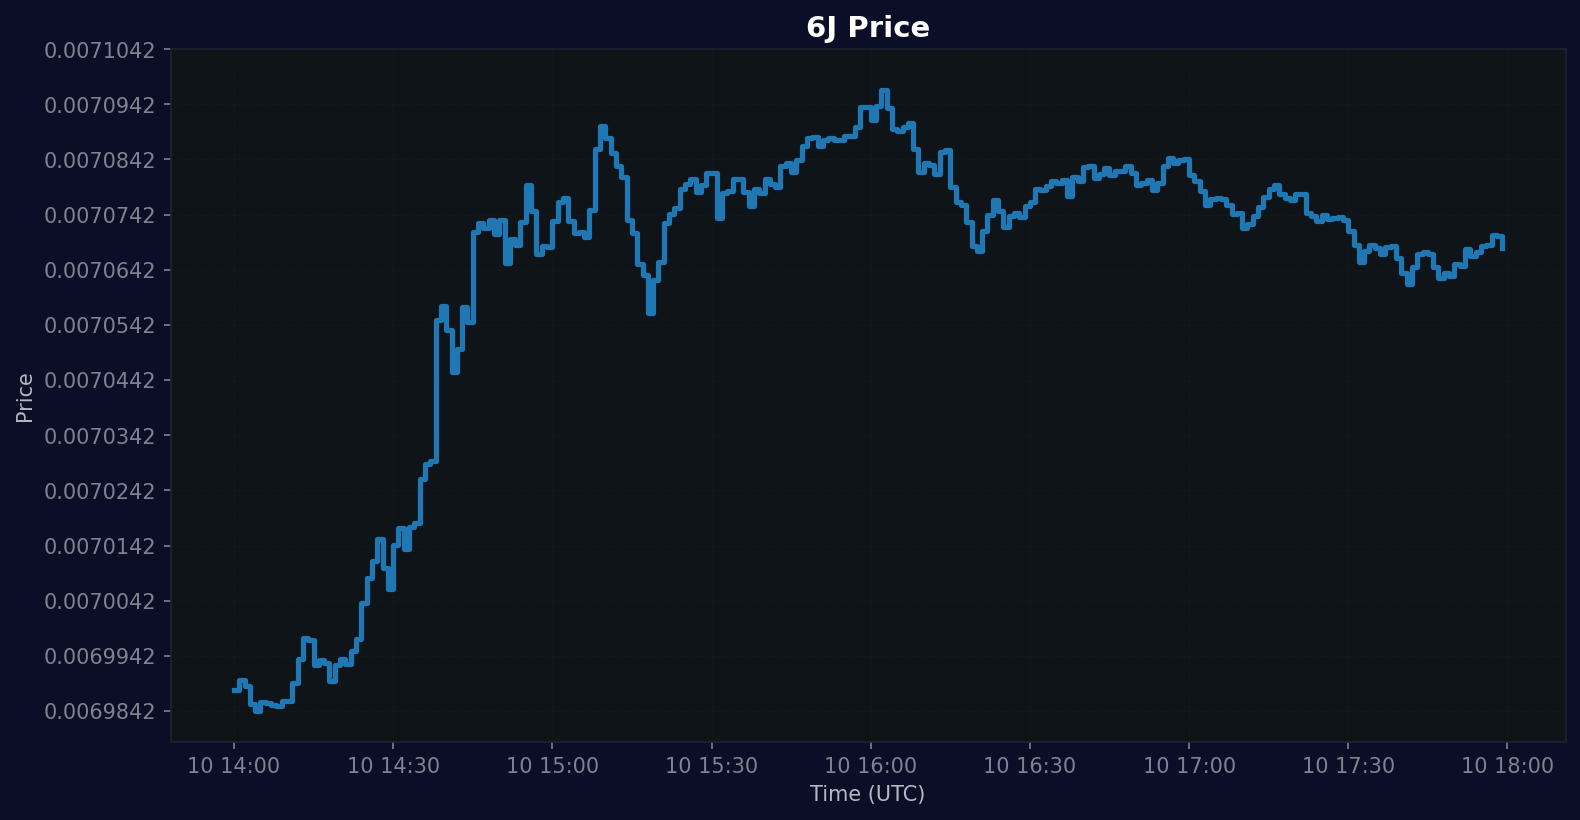

In [174]:
plot_price(vwap, "6J", TICK_SIZE)

In [175]:
"""

BBO Data

    - quoted_bid_price
        - int64
    - quoted_ask_price
        - int64
    - quoted_bid_size
        - uint32
    - quoted_ask_size
        - uint32

"""

import polars as pl

# Method 2: List of glob patterns for MULTIPLE DIRECTORIES
BBO_DATA_GLOB = pl.scan_parquet([
    str(PARQUET_DIR / AvailableDatasets.TBBO__FULL_DAY_2022_11_10__CME_JPY_V / "*.parquet"),
])


# [ ACTUAL FILTER REQUEST FOR PROCESSING ]
bbo_lf = (

    # 0) Glob across all files in data directory
    BBO_DATA_GLOB
    
    # 1) Select only needed columns FIRST (reduces data volume)
    .select([
        "ts_recv",
        "bid_sz_00",
        "ask_sz_00",
        "bid_px_00",
        "ask_px_00",
        "sequence",
        "instrument_id",
    ])

    # 2.) Convert to physical int representation (just stripping data, saved as int64 in Parquet file)
    .with_columns(
        pl.col("ts_recv").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("ts_recv"),
    )
    
    # 3) Filter on raw uint64 epoch values (fastest)
    .filter(
        (pl.col("ts_recv") >= START_DATE_NS) & 
        (pl.col("ts_recv") < END_DATE_NS)
    )
    # .filter(pl.col("side").is_in(["A", "B"])) # Remove "N" side orders
    # .limit(1_000)

)

bbo_weighted = bbo_lf.with_columns(
    pl.col("ts_recv").cast(pl.Datetime("ns"))
).group_by_dynamic(
    "ts_recv",
    every="1m"
).agg(
    bid_weighted=(pl.col("bid_sz_00") * pl.col("bid_px_00")).sum() / pl.col("bid_sz_00").sum(),
    ask_weighted=(pl.col("ask_sz_00") * pl.col("ask_px_00")).sum() / pl.col("ask_sz_00").sum(),
).with_columns(
    total_weighted=(pl.col("bid_weighted") + pl.col("ask_weighted")) * 0.5,
).with_columns(
    spread=pl.col("ask_weighted") - pl.col("bid_weighted"),
    prev_total_weighted=pl.col("total_weighted").shift(1),
    total_weighted_change=pl.col("total_weighted") - pl.col("total_weighted").shift(1),
    pct_return=(pl.col("total_weighted") - pl.col("total_weighted").shift(1)) / pl.col("total_weighted").shift(1),
    log_return=pl.col("total_weighted").log() - pl.col("total_weighted").shift(1).log(),
    ts_recv_dt=pl.from_epoch(pl.col("ts_recv"), time_unit="ns"),
    Price=(pl.col("total_weighted") / 1e9),
).select([
    "ts_recv",
    "bid_weighted",
    "ask_weighted",
    "total_weighted",
    "spread",
    "prev_total_weighted",
    "total_weighted_change",
    "pct_return",
    "log_return",
    "ts_recv_dt",
    "Price",
]).collect()

data shape: (240, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ ts_recv   ┆ bid_weigh ┆ ask_weigh ┆ total_wei ┆ … ┆ pct_retur ┆ log_retur ┆ ts_recv_d ┆ Price    │
│ ---       ┆ ted       ┆ ted       ┆ ghted     ┆   ┆ n         ┆ n         ┆ t         ┆ ---      │
│ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ f64      │
│ ns]       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ datetime[ ┆          │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆ ns]       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2022-11-1 ┆ 6.9876e6  ┆ 6.9887e6  ┆ 6.9881e6  ┆ … ┆ null      ┆ null      ┆ 2022-11-1 ┆ 0.006988 │
│ 0         ┆           ┆           ┆           ┆   ┆           ┆           ┆ 0         ┆          │
│ 14:00:00  ┆           ┆           ┆           ┆   ┆           ┆    

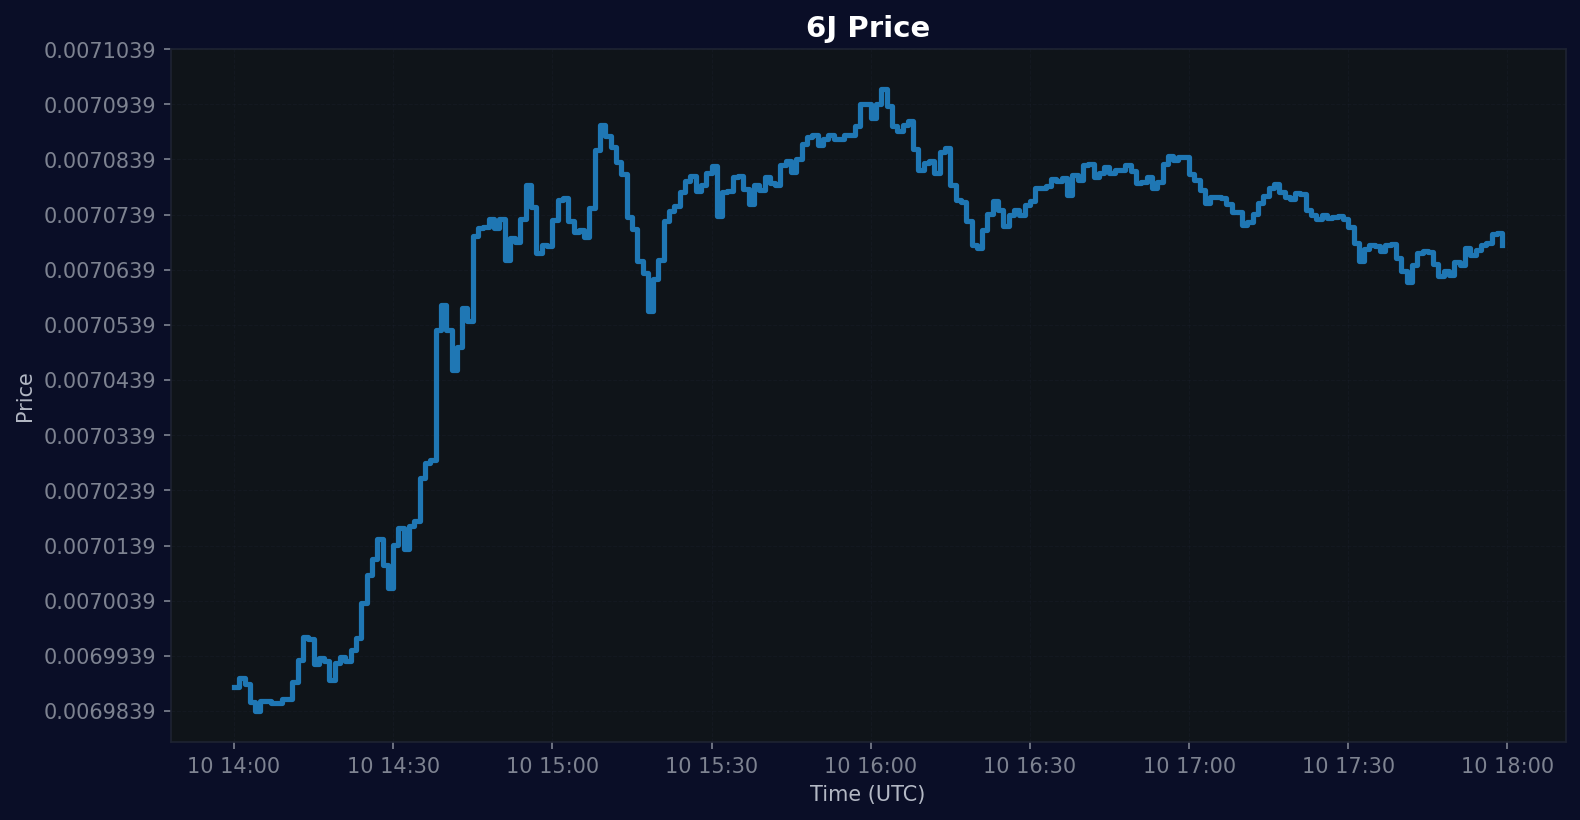

In [176]:
plot_price(bbo_weighted, "6J", TICK_SIZE)

In [177]:
def plot_price_comparison(
    data_a: pl.DataFrame,
    data_b: pl.DataFrame,
    symbol_a: str,
    symbol_b: str,
    tick_size_a: float,
    tick_size_b: float,
) -> None:
    """
    Plot two VWAP prices over time with Bloomberg Terminal styling.
    """
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.0,
    })
    
    # Calculate price ranges
    price_min_a = data_a.select(pl.col("Price").min()).item()
    price_max_a = data_a.select(pl.col("Price").max()).item()
    price_min_b = data_b.select(pl.col("Price").min()).item()
    price_max_b = data_b.select(pl.col("Price").max()).item()
    
    y_tick_range_a = np.arange(
        price_min_a,
        price_max_a + tick_size_a,
        tick_size_a,
    )
    
    y_tick_range_b = np.arange(
        price_min_b,
        price_max_b + tick_size_b,
        tick_size_b,
    )
    
    # Create figure with dual Y-axes
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot Asset A on left axis
    color_a = '#00d4aa'
    ax1.plot(
        data_a["ts_recv_dt"],
        data_a["Price"],
        color=color_a,
        linewidth=2.5,
        drawstyle="steps-post",
        label=f"{symbol_a} (A)",
    )
    ax1.set_xlabel("Time (UTC)", color='#b3b8c4')
    ax1.set_ylabel(f"Price A ({symbol_a})", color=color_a)
    ax1.tick_params(axis='y', labelcolor=color_a)
    ax1.set_yticks(y_tick_range_a)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.2f}'))
    
    # Create second Y-axis for Asset B
    ax2 = ax1.twinx()
    color_b = '#ffd93d'
    ax2.plot(
        data_b["ts_recv_dt"],
        data_b["Price"],
        color=color_b,
        linewidth=2.5,
        drawstyle="steps-post",
        label=f"{symbol_b} (B)",
    )
    ax2.set_ylabel(f"Price B ({symbol_b})", color=color_b)
    ax2.tick_params(axis='y', labelcolor=color_b)
    ax2.set_yticks(y_tick_range_b)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.2f}'))
    
    # Remove top spine
    ax1.spines['top'].set_visible(False)
    
    # Set title
    plt.title(f"{symbol_a} vs {symbol_b} Price Comparison", color='#ffffff', fontweight='bold')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left',
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9,
    )
    
    # Format X-axis dates
    if hasattr(data_a["ts_recv_dt"].dtype, 'time_unit'):
        import matplotlib.dates as mdates
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

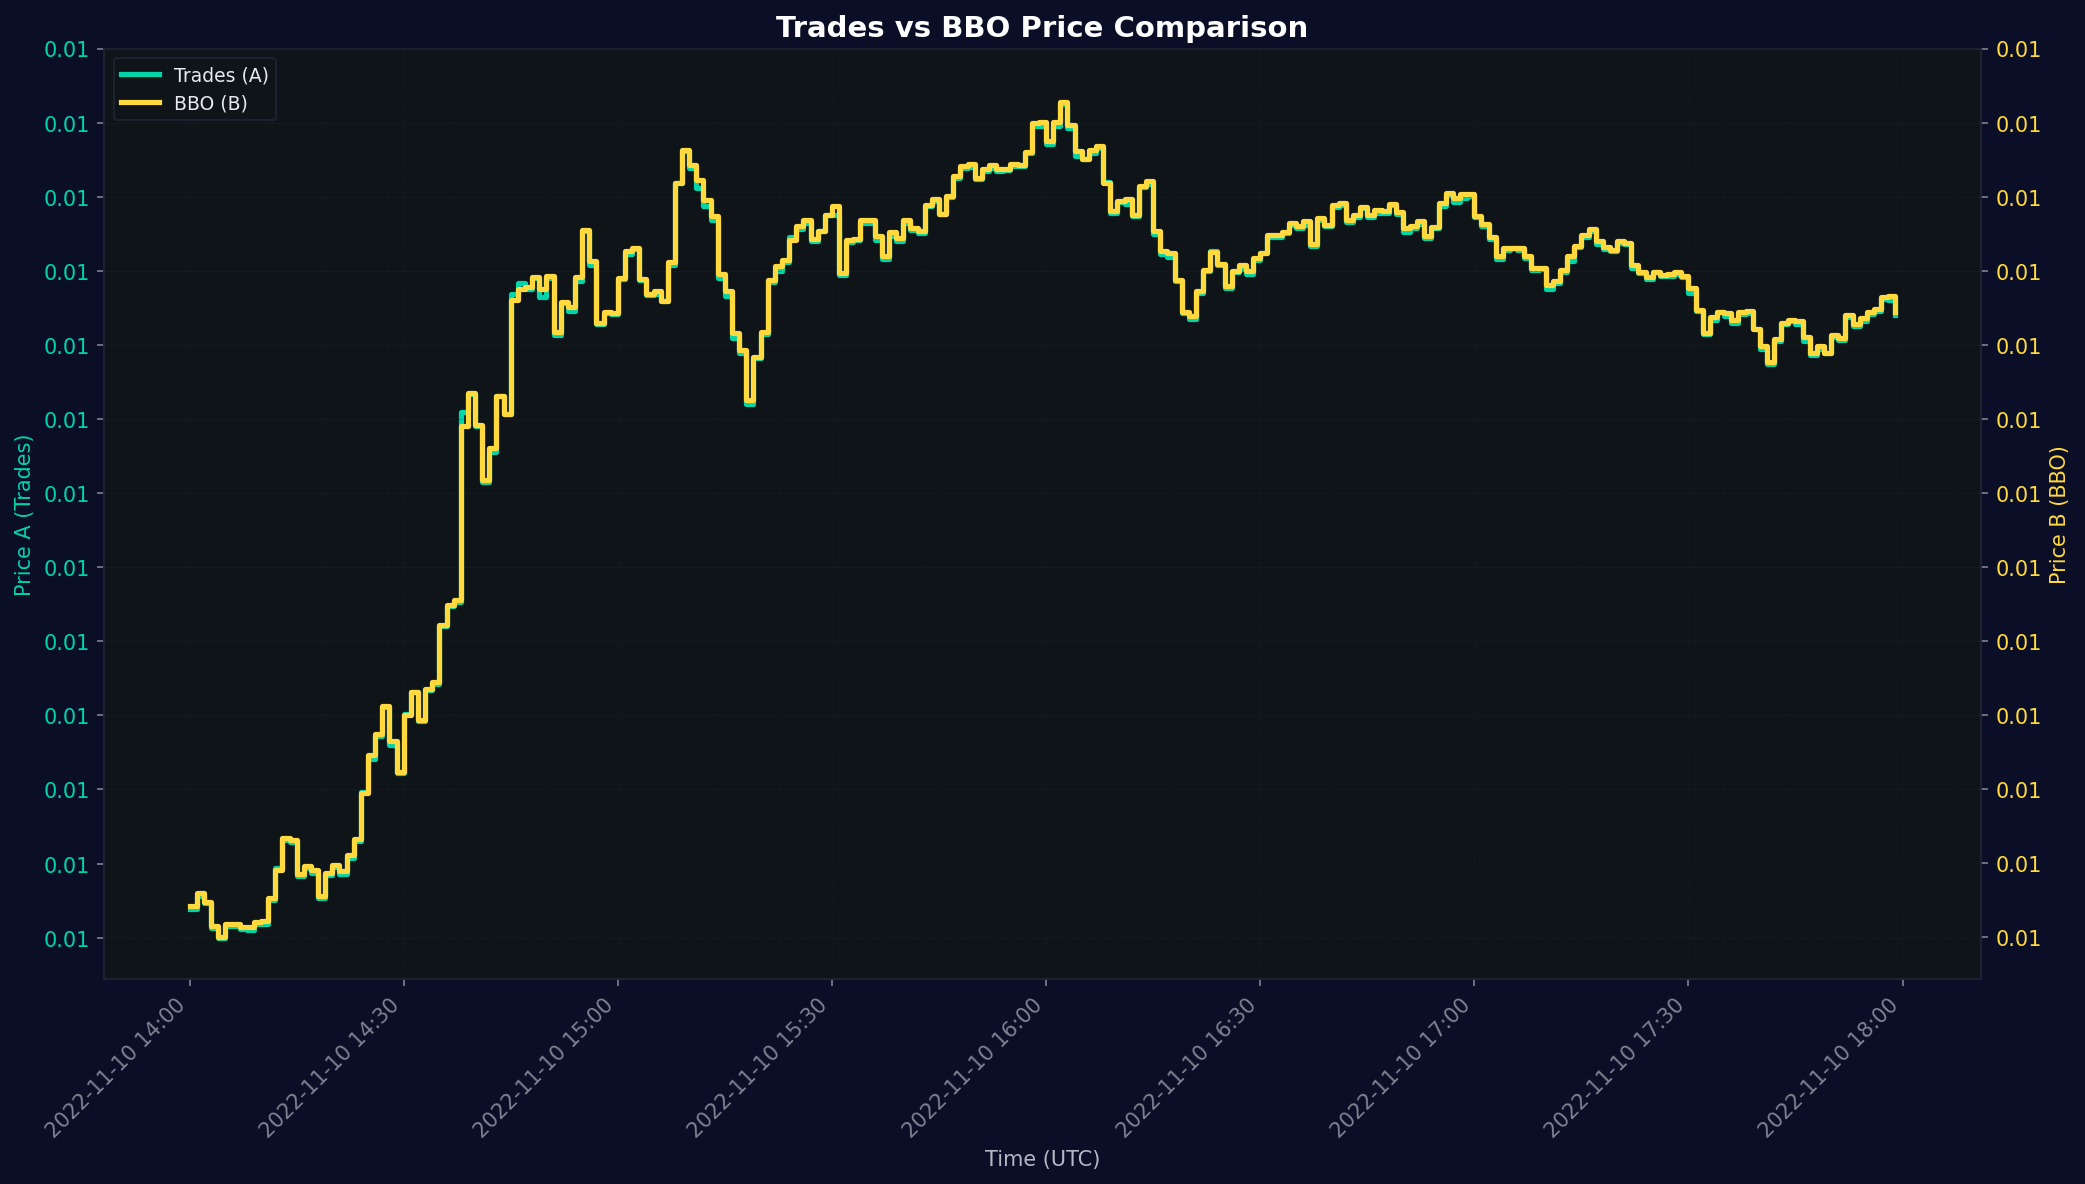

In [178]:
plot_price_comparison(vwap, bbo_weighted, "Trades", "BBO", TICK_SIZE, TICK_SIZE)

In [179]:
def plot_price_spread(
    data_a: pl.DataFrame,
    data_b: pl.DataFrame,
    symbol_a: str,
    symbol_b: str,
) -> None:
    """
    Plot the spread (difference) between two VWAP prices with Bloomberg Terminal styling.
    """
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Align timestamps and calculate spread
    # Assuming data needs to be joined on timestamp
    spread_data = data_a.join(
        data_b.select(["ts_recv_dt", pl.col("Price").alias("Price_B")]),
        on="ts_recv_dt",
        how="inner",
    ).with_columns(
        (pl.col("Price") - pl.col("Price_B")).alias("Spread")
    )
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Determine color based on positive/negative spread
    spread_values = spread_data["Spread"].to_numpy()
    colors = np.where(spread_values >= 0, '#00ff88', '#ff3366')
    
    # Plot spread as line
    ax.plot(
        spread_data["ts_recv_dt"],
        spread_data["Spread"],
        color='#00d4aa',
        linewidth=2.5,
        drawstyle="steps-post",
    )
    
    # Add zero line reference
    ax.axhline(y=0, color='#ffffff', linestyle='--', linewidth=0.8, alpha=0.3)
    
    # Optional: Fill area under curve with color coding
    ax.fill_between(
        spread_data["ts_recv_dt"],
        spread_data["Spread"],
        0,
        where=(spread_data["Spread"] >= 0),
        color='#00ff88',
        alpha=0.15,
        step='post',
    )
    ax.fill_between(
        spread_data["ts_recv_dt"],
        spread_data["Spread"],
        0,
        where=(spread_data["Spread"] < 0),
        color='#ff3366',
        alpha=0.15,
        step='post',
    )
    
    # Set labels and title
    ax.set_xlabel("Time (UTC)", color='#b3b8c4')
    ax.set_ylabel(f"Spread ({symbol_a} - {symbol_b})", color='#b3b8c4')
    ax.set_title(f"Price Spread: {symbol_a} - {symbol_b}", color='#ffffff', fontweight='bold')
    
    # Format Y-axis with appropriate precision
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.4f}'))
    
    # Position Y-axis on right side
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    
    # Remove top and left spines
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Format X-axis dates
    if hasattr(spread_data["ts_recv_dt"].dtype, 'time_unit'):
        import matplotlib.dates as mdates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

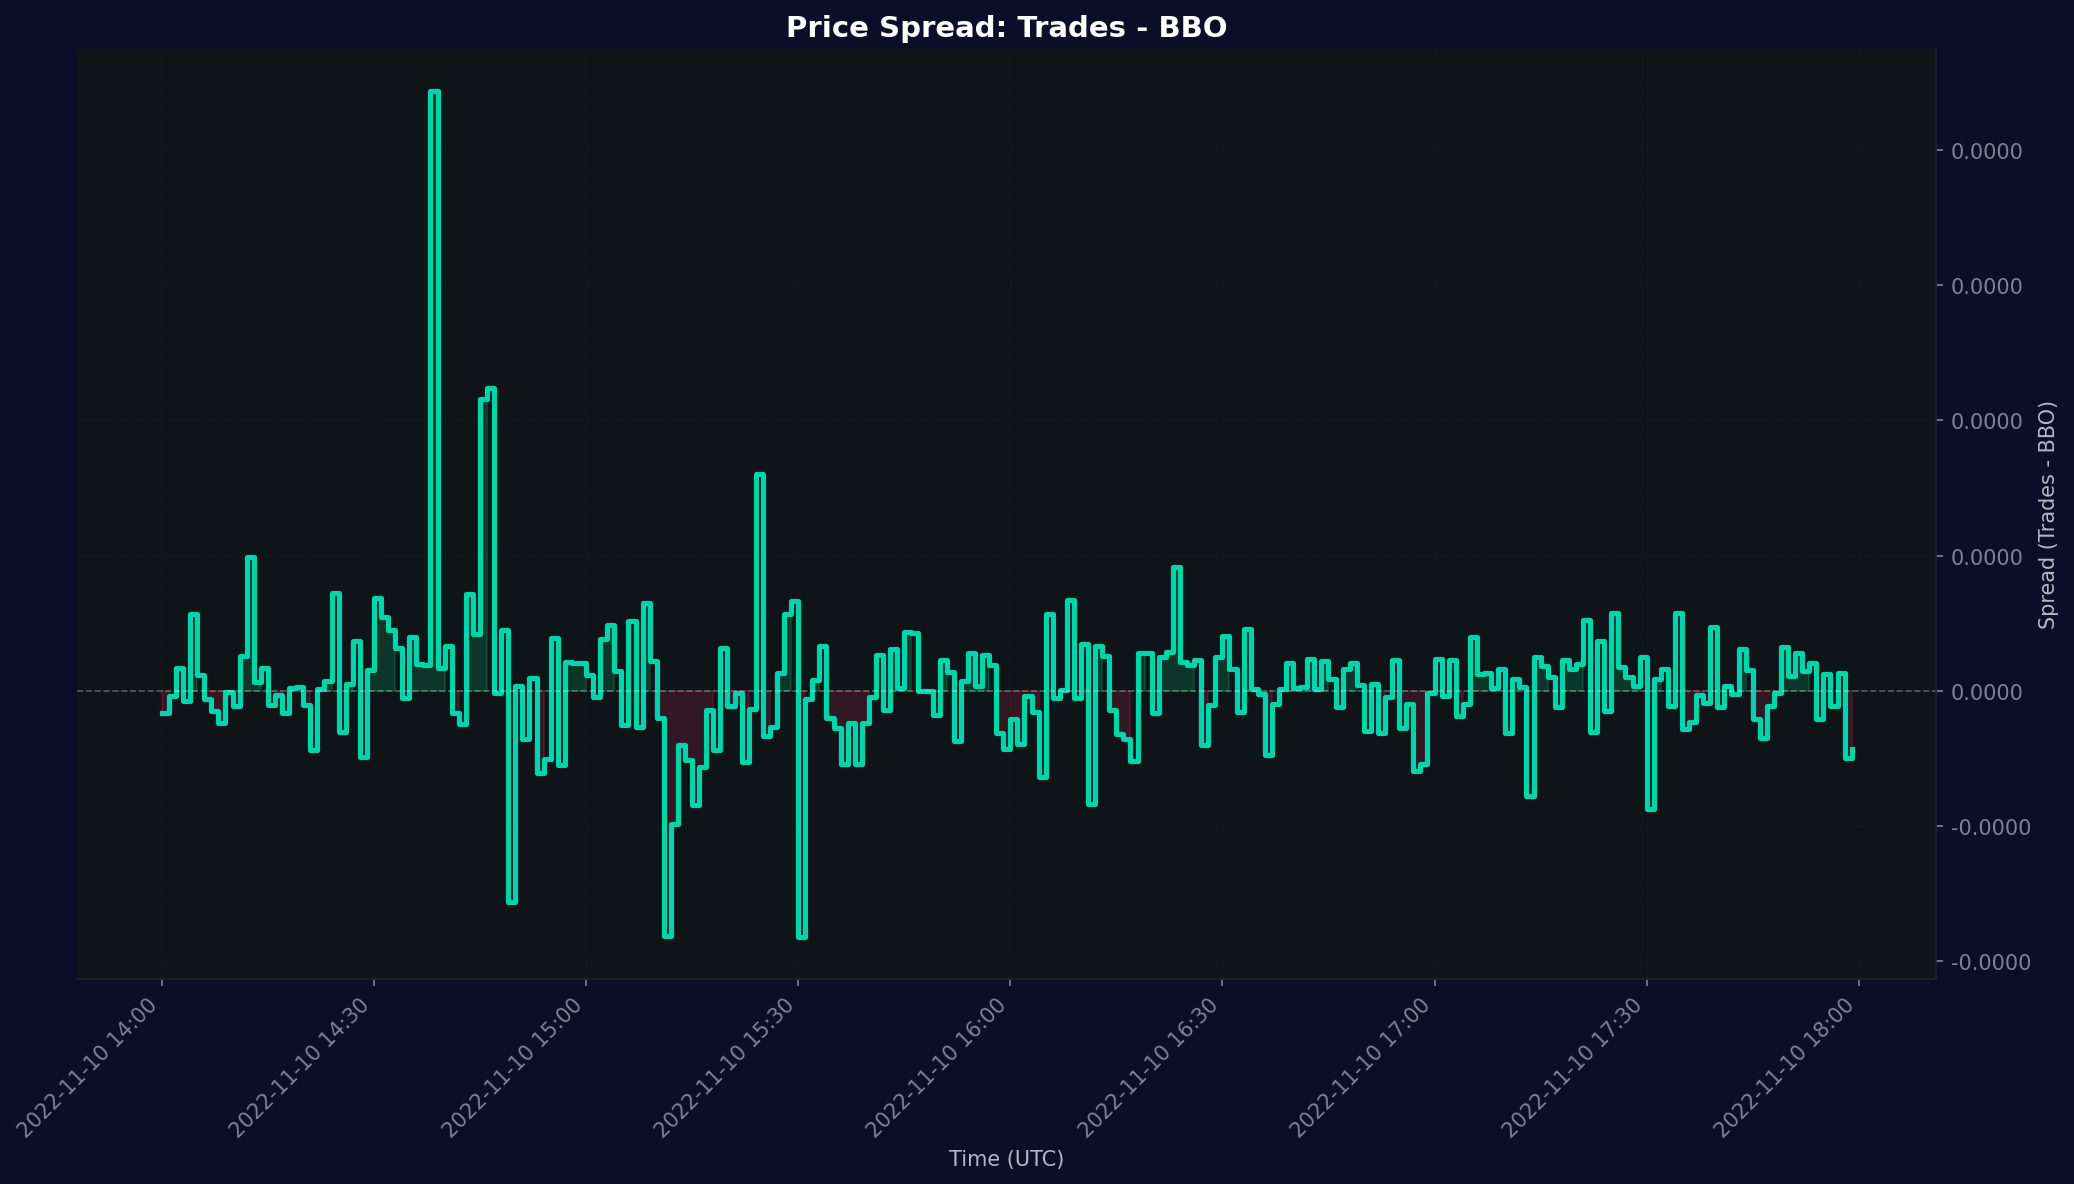

In [180]:
plot_price_spread(vwap, bbo_weighted, "Trades", "BBO")

In [181]:

IB1500_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_ib1500/2214_Nov_15_25/bucket/interval/bucket_interval_consolidated.parquet")

# ============================================================================
# [START] - Import Filters
# ============================================================================

# Data files to glob for processing
IB_DATA_GLOB = pl.scan_parquet(str(IB1500_DIR))


# {IntervalBucket - 1500} [ ACTUAL FILTER REQUEST FOR PROCESSING ]

"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame

imbalance_size_signed_ratio_atanh_mean

delta_midpoint_vwap_log_sum

"""


ib_lf = (
    IB_DATA_GLOB
    .with_columns(
        (pl.col("imbalance_size_signed_ratio_atanh_mean").rank(method="average").truediv(pl.len()) * 100).alias("imbalance_ecdf_pct")
    )
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .select([
        "id",
        pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
        pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
        "time_elapsed_ns_total",
        "pace_of_orders_mean",
        "time_elapsed_ns_mean",
        "imbalance_size_signed_ratio_mean",
        "bucket_delta_imbalance_size_abs_ratio_mean_logit",
        "imbalance_size_signed_ratio_atanh_mean",
        "imbalance_ecdf_pct",
    ])
    .with_columns([
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_time"),
        (pl.col("time_elapsed_ns_mean") / 1e9).alias("time_elapsed_ns_mean"),
    ])
).collect()



In [182]:
"""
example price chart before we make the correl table
"""

# f"{symbol} (JPY/USD) Price vs. Volume-Time"

'\nexample price chart before we make the correl table\n'

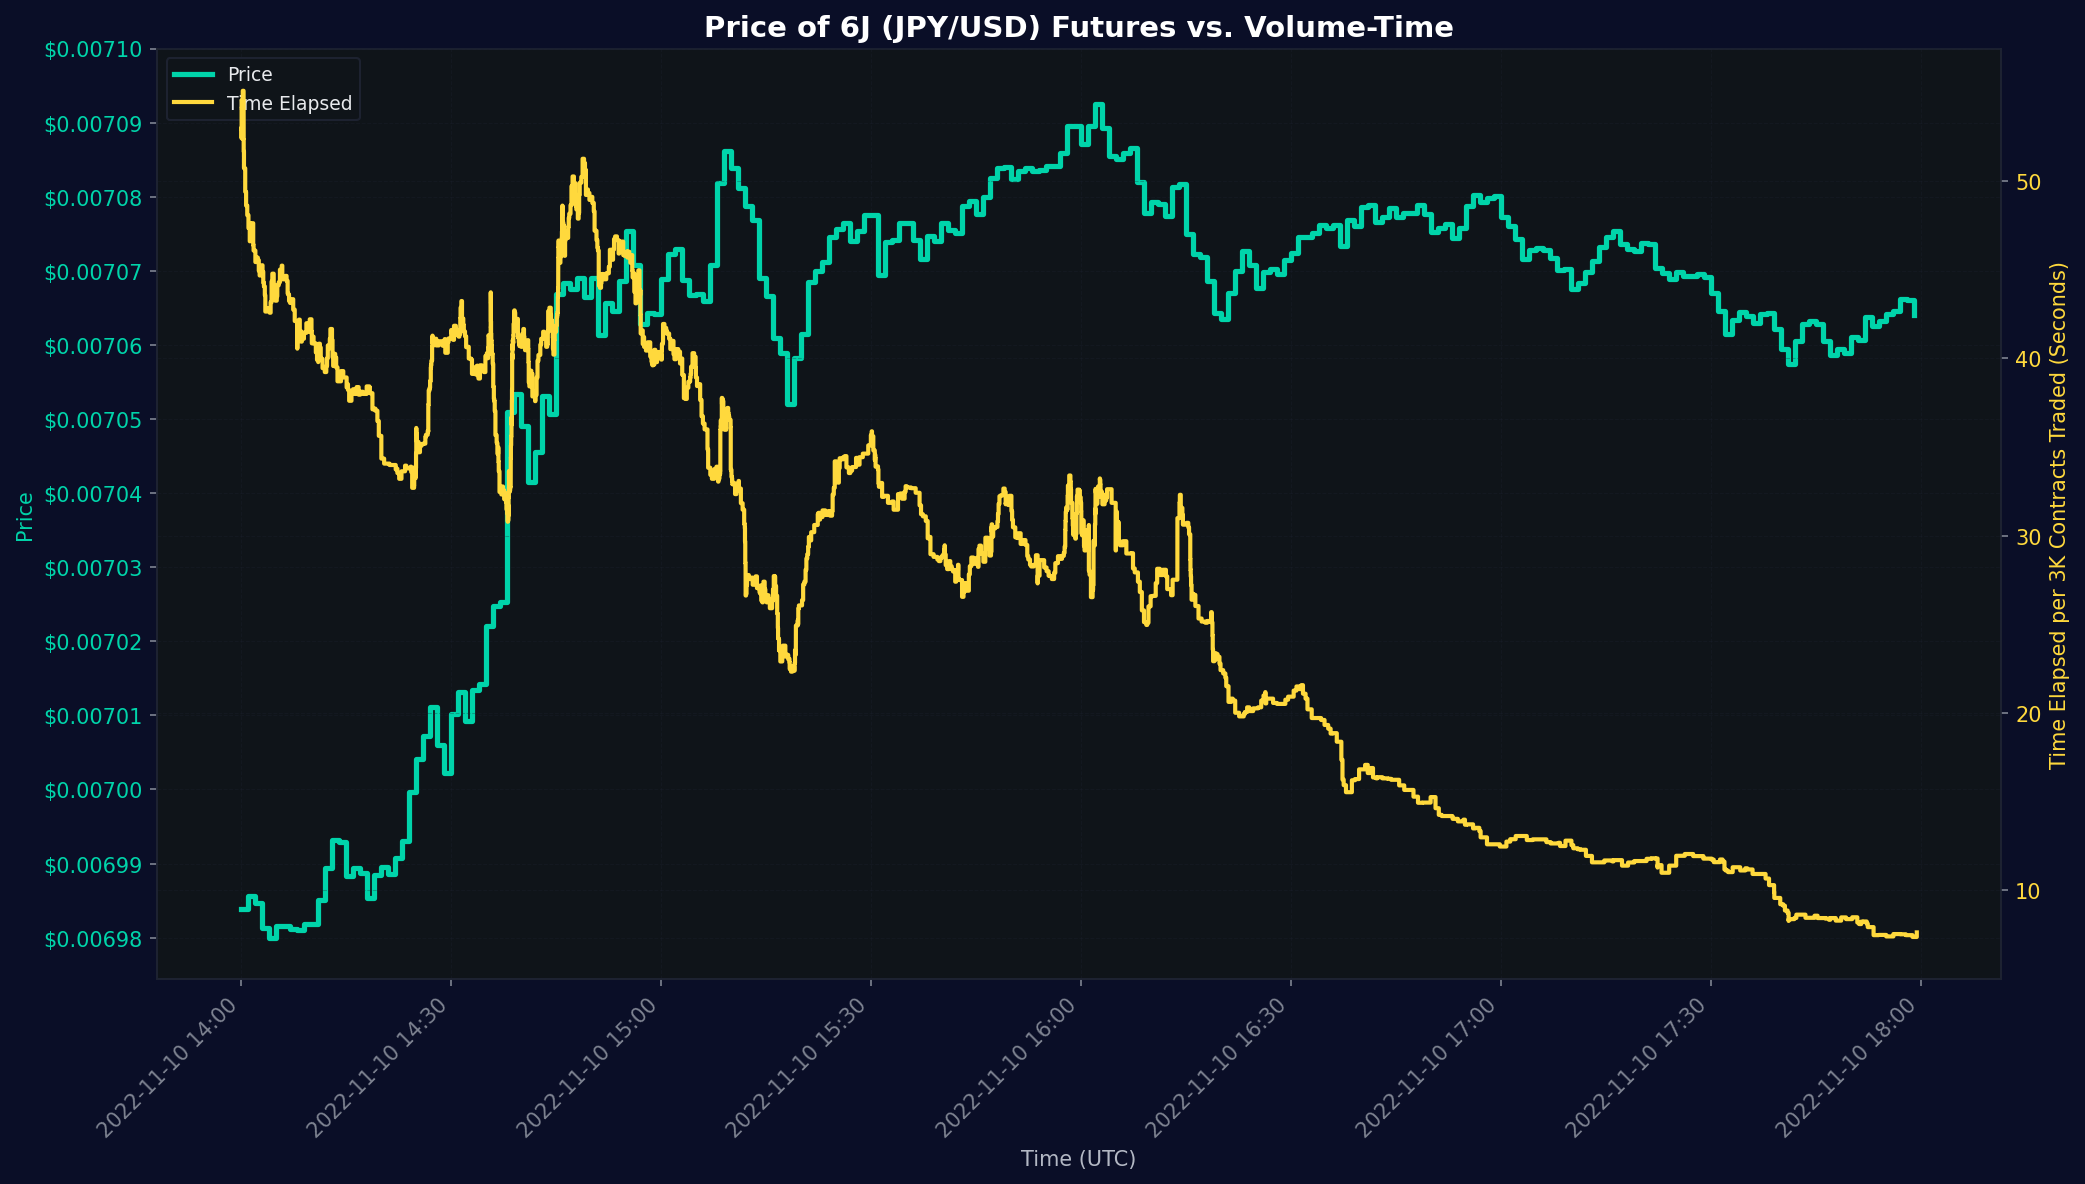

In [183]:
def plot_price_and_elapsed2(
    price_data: pl.DataFrame,
    ib_lf: pl.DataFrame,
    symbol: str,
    tick_size: float,
) -> None:
    """
    Plot VWAP price and volume bar time elapsed on dual y-axes with Bloomberg Terminal styling.
    """
    
    # Apply Bloomberg theme
    plt.rcParams.update({
        'figure.facecolor': '#0a0e27',
        'axes.facecolor': '#0f1419',
        'axes.edgecolor': '#1e2332',
        'axes.labelcolor': '#b3b8c4',
        'axes.titlecolor': '#ffffff',
        'text.color': '#e8eaed',
        'xtick.color': '#7e8391',
        'ytick.color': '#7e8391',
        'grid.color': '#1e2332',
        'grid.linestyle': '--',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'figure.dpi': 150,
        'axes.grid': True,
        'axes.axisbelow': True,
        'font.family': 'sans-serif',
        'font.size': 10,
        'axes.titlesize': 14,
        'axes.titleweight': 'bold',
        'lines.linewidth': 2.5,
    })
    
    # Calculate price range
    price_min = price_data.select(pl.col("Price").min()).item()
    price_max = price_data.select(pl.col("Price").max()).item()
    
    y_tick_range = np.arange(
        price_min,
        price_max + tick_size,
        tick_size,
    )

    # Sort volume bar data
    ib_lf = ib_lf.sort("end_time")

    # Create figure and primary axis
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Plot price on left y-axis
    color = '#00d4aa'
    ax1.set_xlabel("Time (UTC)", color='#b3b8c4')
    ax1.set_ylabel("Price", color=color)
    ax1.plot(
        price_data["ts_recv_dt"],
        price_data["Price"],
        color=color,
        linewidth=2.5,
        drawstyle="steps-post",
        label="Price",
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.set_yticks(y_tick_range)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.5f}'))

    # Create secondary y-axis for time elapsed
    ax2 = ax1.twinx()
    color = '#ffd93d'
    ax2.set_ylabel("Time Elapsed per 3K Contracts Traded (Seconds)", color=color)
    ax2.plot(
        ib_lf["end_time"],
        ib_lf["imbalance_ecdf_pct"],
        color=color,
        linewidth=2.0,
        drawstyle="steps-post",
        label="Time Elapsed",
    )
    ax2.tick_params(axis="y", labelcolor=color)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))

    # Remove top spine
    ax1.spines['top'].set_visible(False)
    
    # Title
    plt.title("Price of 6J (JPY/USD) Futures vs. Volume-Time", color='#ffffff', fontweight='bold')
    
    # Add legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left',
        framealpha=0.95,
        facecolor='#0f1419',
        edgecolor='#1e2332',
        fontsize=9,
    )
    
    # Format X-axis dates
    if hasattr(price_data["ts_recv_dt"].dtype, 'time_unit'):
        import matplotlib.dates as mdates
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    fig.tight_layout()
    plt.show()


plot_price_and_elapsed2(vwap, ib_lf, "6J", TICK_SIZE)

wuotes being pulled, liquidity drying up, trades slowing down, price gaps/jumps, trading frantically resumes to find new quilibrium. first

In [184]:
"""

| id | ts? | imbalance | ECDF(imbalance) | Log_Return(T + 1) |

Correl of ECDF / Log

How to find T + 1/ -1? if we use interval buckets? ...

Review the paper...


"""

'\n\n| id | ts? | imbalance | ECDF(imbalance) | Log_Return(T + 1) |\n\nCorrel of ECDF / Log\n\nHow to find T + 1/ -1? if we use interval buckets? ...\n\nReview the paper...\n\n\n'

In [185]:
"""

build a correl table

review paper first...

point of using the log? ln(vpin)

current abs(return) AND previous VPIN

pearsons correlation

2 conditionals VPIN|abs(return) and abs(return)|VPIN
5-percentiles & return sized bins

imbalance signed?

---

how are we calculating "the next bucket" ...?


BUCKET SIZE IS DIFFERENT THAN BUCKET LOOKBACK OOOOOOOF

METRIC = 50 BUCKETS, METRIC = 1 DAY ughhhhhh

BUCKET = 1/50th of a day!!!

find next 1/50th from interval?

"""

'\n\nbuild a correl table\n\nreview paper first...\n\npoint of using the log? ln(vpin)\n\ncurrent abs(return) AND previous VPIN\n\npearsons correlation\n\n2 conditionals VPIN|abs(return) and abs(return)|VPIN\n5-percentiles & return sized bins\n\nimbalance signed?\n\n---\n\nhow are we calculating "the next bucket" ...?\n\n\nBUCKET SIZE IS DIFFERENT THAN BUCKET LOOKBACK OOOOOOOF\n\nMETRIC = 50 BUCKETS, METRIC = 1 DAY ughhhhhh\n\nBUCKET = 1/50th of a day!!!\n\nfind next 1/50th from interval?\n\n'

In [186]:

FB30_DIR = Path("/Users/number6/Projects/Bimini/pool_vb100_fb30/1942_Nov_16_25/bucket/fixed/bucket_fixed_consolidated.parquet")

# ============================================================================
# [START] - Import Filters
# ============================================================================

# Data files to glob for processing
FB30_DATA_GLOB = pl.scan_parquet(str(FB30_DIR))


# {FixedBucket - 30} [ ACTUAL FILTER REQUEST FOR PROCESSING ]

"""

Rolling average container

Container_Size > Search_Range

Thus only consider end time for each new interval of the rolling average that would be available in the time frame

imbalance_size_signed_ratio_atanh_mean

delta_midpoint_vwap_log_sum

"""

metrics_from_fb30 = (
    FB30_DATA_GLOB
    .with_columns([
        (pl.col("volume_buy_sum").cast(pl.Int64) - pl.col("volume_sell_sum").cast(pl.Int64)).alias("volume_imbalance_signed"),
    ])
    .with_columns(
        metric=pl.int_range(pl.len()) // 1
    )
    .group_by("metric").agg([
        pl.col("id").first(),
        pl.col("start_ts_ns").first(),
        pl.col("end_ts_ns").last(),
        pl.col("time_elapsed_ns_total").sum().alias("time_elapsed_ns_total"),
        pl.col("volume_total_sum").sum().alias("volume_total_sum"),
        pl.col("volume_buy_sum").sum().alias("volume_buy_sum"),
        pl.col("volume_sell_sum").sum().alias("volume_sell_sum"),
        pl.col("imbalance_buy_ratio_logit_mean").mean().alias("ratio"),
        pl.col("volume_imbalance_signed").sum().alias("volume_imbalance_signed"),
        pl.col("delta_midpoint_vwap_log_sum").sum().alias("total_log_return__midpoint_vwap"),
        (pl.col("delta_midpoint_vwap_log_sum").sum()).abs().alias("total_log_return__midpoint_vwap_abs"),
    ])
    .sort("metric")
    .with_columns(
        pl.col("volume_imbalance_signed").abs().alias("volume_imbalance_abs")
    )
    .with_columns([
        (pl.col("volume_imbalance_signed").rank(method="average").truediv(pl.len())).log().alias("log_ecdf__volume_imbalance_signed"),
        (pl.col("volume_imbalance_abs").rank(method="average").truediv(pl.len())).log().alias("log_ecdf__volume_imbalance_abs"),
        (pl.col("volume_imbalance_signed").rank(method="average").truediv(pl.len()) * 100).alias("ecdf_pct__volume_imbalance_signed"),
        (pl.col("volume_imbalance_abs").rank(method="average").truediv(pl.len()) * 100).alias("ecdf_pct__volume_imbalance_abs"),
    ])
    .drop("metric")
)


metrics_event = (
    metrics_from_fb30
    .filter(
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") >= START_DATE_NS) & 
        (pl.col("end_ts_ns").dt.epoch(time_unit="ns") <= END_DATE_NS)
    )
    .select([
        "id",
        pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
        pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
        "time_elapsed_ns_total",
        "volume_total_sum",
        "volume_buy_sum",
        "volume_sell_sum",
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_time"),
        "volume_imbalance_signed",
        "volume_imbalance_abs",
        "total_log_return__midpoint_vwap",
        "total_log_return__midpoint_vwap_abs",
        "log_ecdf__volume_imbalance_signed",
        "log_ecdf__volume_imbalance_abs",
        "ecdf_pct__volume_imbalance_signed",
        "ecdf_pct__volume_imbalance_abs",
        "ratio"
    ])
).collect()


metrics_all = (
    metrics_from_fb30
    .select([
        "id",
        pl.col("start_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("start_ts_ns"),
        pl.col("end_ts_ns").dt.epoch(time_unit="ns").cast(pl.UInt64).alias("end_ts_ns"),
        "time_elapsed_ns_total",
        "volume_total_sum",
        "volume_buy_sum",
        "volume_sell_sum",
        pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_time"),
        "volume_imbalance_signed",
        "volume_imbalance_abs",
        "total_log_return__midpoint_vwap",
        "total_log_return__midpoint_vwap_abs",
        "log_ecdf__volume_imbalance_signed",
        "log_ecdf__volume_imbalance_abs",
        "ecdf_pct__volume_imbalance_signed",
        "ecdf_pct__volume_imbalance_abs",
    ])
)

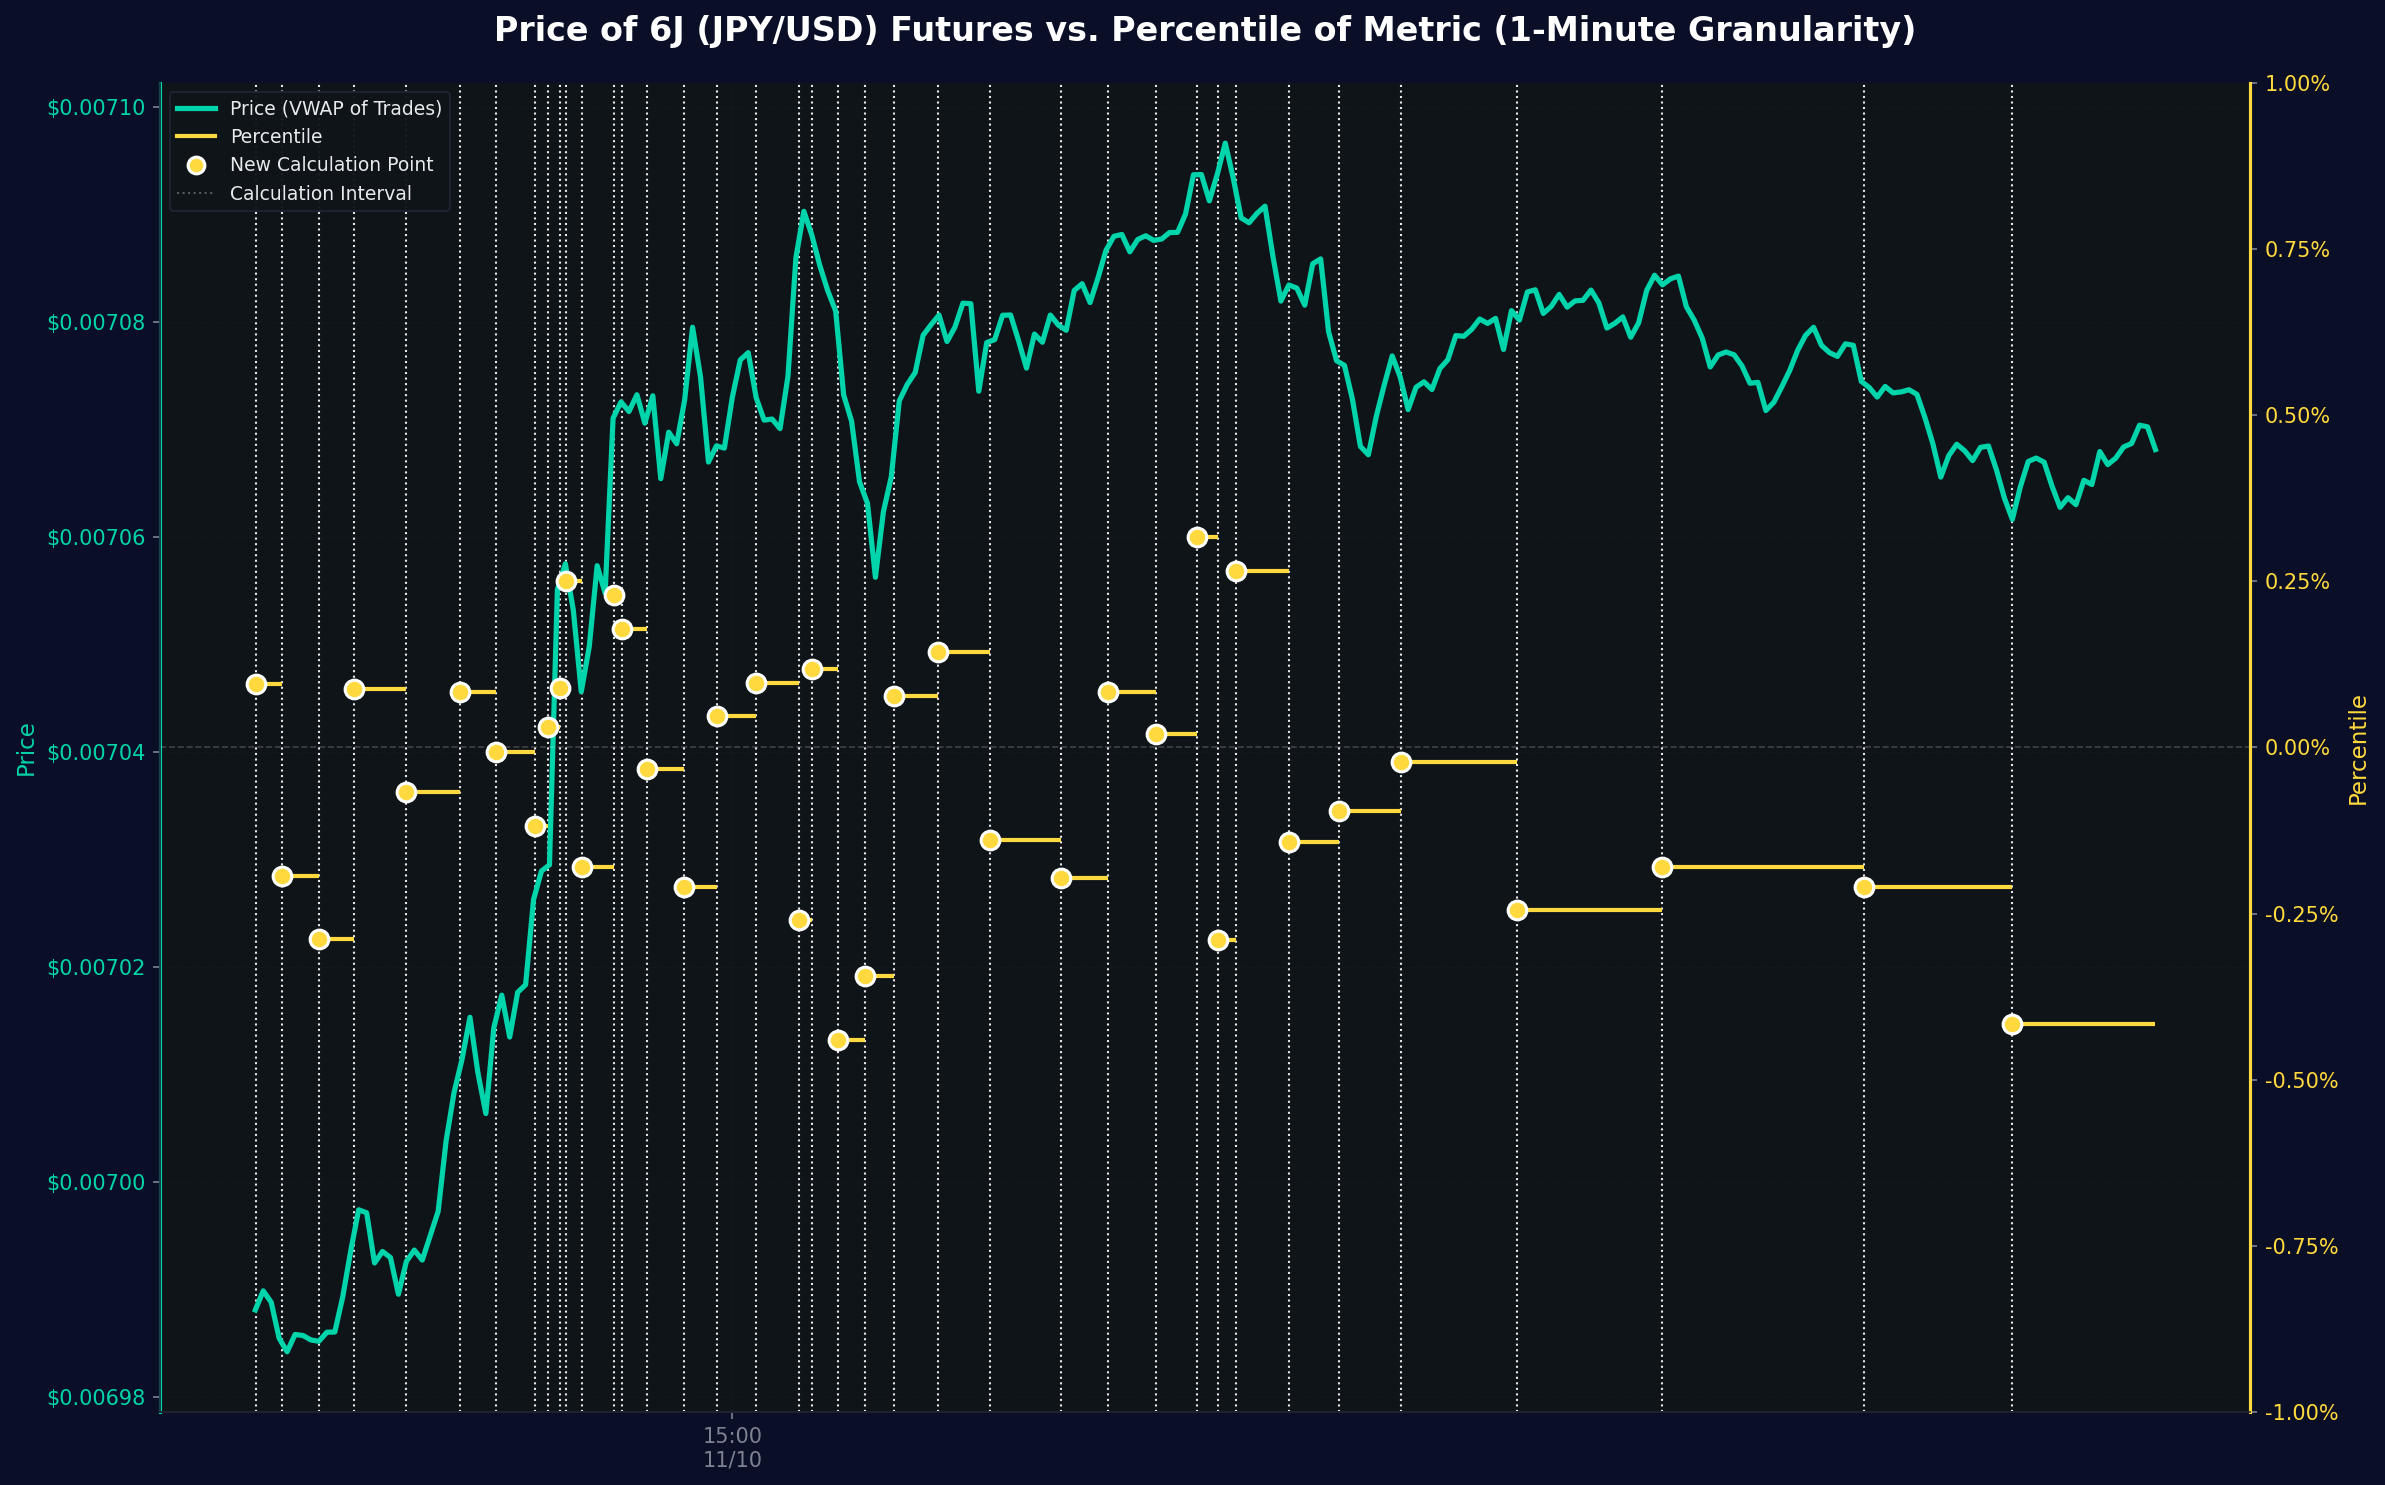

In [187]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import polars as pl
from datetime import datetime, timedelta

# Apply Bloomberg theme
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0f1419',
    'axes.edgecolor': '#1e2332',
    'axes.labelcolor': '#b3b8c4',
    'axes.titlecolor': '#ffffff',
    'text.color': '#e8eaed',
    'xtick.color': '#7e8391',
    'ytick.color': '#7e8391',
    'grid.color': '#1e2332',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    'figure.dpi': 150,
    'axes.grid': True,
    'axes.axisbelow': True,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'lines.linewidth': 2.5,
})

# Load your data
# price_df should have columns: ts_recv (ns), price
# percentile_df should have columns: end_ts_ns (ns), percentile_value

# Convert to datetime
price_df = vwap.with_columns(
    ts_recv_dt=pl.from_epoch(pl.col("ts_recv"), time_unit="ns")
)

percentile_df = metrics_event.with_columns(
    pl.from_epoch(pl.col("end_ts_ns"), time_unit="ns").alias("end_time")
)

# Convert to pandas for matplotlib compatibility
price_pd = price_df.select(["ts_recv_dt", "Price"]).to_pandas()
percentile_pd = percentile_df.select(["end_time", "ratio"]).to_pandas()

# Sort by time
price_pd = price_pd.sort_values("ts_recv_dt")
percentile_pd = percentile_pd.sort_values("end_time")

# Create figure with dual Y-axes
fig, ax1 = plt.subplots(figsize=(16, 10))

# Left Y-axis: Price
line1 = ax1.plot(price_pd["ts_recv_dt"], price_pd["Price"], 
                 color='#00d4aa', linewidth=2.5, label='Price (VWAP of Trades)', zorder=2)
ax1.set_ylabel('Price', fontsize=11, color='#00d4aa')
ax1.tick_params(axis='y', labelcolor='#00d4aa')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.5f}'))

# Right Y-axis: Percentile
ax2 = ax1.twinx()

# Plot step function to show percentile held constant until next calculation
percentile_times = percentile_pd["end_time"].values
percentile_values = percentile_pd["ratio"].values

for i in range(len(percentile_times) - 1):
    ax2.hlines(percentile_values[i], percentile_times[i], percentile_times[i+1],
               colors='#ffd93d', linewidth=2.0, zorder=3)

# Extend last value to end of chart
if len(percentile_times) > 0:
    ax2.hlines(percentile_values[-1], percentile_times[-1], price_pd["ts_recv_dt"].iloc[-1],
               colors='#ffd93d', linewidth=2.0, zorder=3)

# Add dots at calculation points to emphasize lookahead awareness
ax2.scatter(percentile_times, percentile_values, color='#ffd93d', 
            s=80, zorder=4, edgecolors='#ffffff', linewidths=1.5)

# Add vertical dotted lines at each percentile calculation point
for ptime in percentile_times:
    ax1.axvline(x=ptime, color="#ffffff", alpha=0.9, linestyle=':', 
                linewidth=1.0, zorder=1)

ax2.set_ylabel('Percentile', fontsize=11, color='#ffd93d')
ax2.tick_params(axis='y', labelcolor='#ffd93d')
ax2.set_ylim(-1, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}%'))

# Add reference lines at percentile bounds
ax2.axhline(y=0, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
ax2.axhline(y=50, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)
ax2.axhline(y=100, color='#ffffff', alpha=0.2, linestyle='--', linewidth=0.8)

# Format X-axis for 24-hour UTC with date
def format_datetime(x, pos):
    dt = mdates.num2date(x)
    return dt.strftime('%H:%M\n%m/%d')

ax1.xaxis.set_major_formatter(plt.FuncFormatter(format_datetime))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Label every 6 hours
plt.setp(ax1.xaxis.get_majorticklabels(), ha='center')

# Title
ax1.set_title('Price of 6J (JPY/USD) Futures vs. Percentile of Metric (1-Minute Granularity)', 
              fontsize=16, weight='bold', color='#ffffff', pad=20)

# Remove top spine
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Style remaining spines
ax1.spines['left'].set_color('#00d4aa')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_color('#1e2332')
ax2.spines['right'].set_color('#ffd93d')
ax2.spines['right'].set_linewidth(1.5)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2 = [plt.Line2D([0], [0], color='#ffd93d', linewidth=2.0),
          plt.Line2D([0], [0], marker='o', color='#ffd93d', linewidth=0, 
                     markersize=8, markeredgecolor='#ffffff', markeredgewidth=1.5),
          plt.Line2D([0], [0], color='#ffffff', alpha=0.3, linestyle=':', linewidth=1.0)]
labels2 = ['Percentile', 'New Calculation Point', 'Calculation Interval']

ax1.legend(lines1 + lines2, labels1 + labels2, 
          loc='upper left', framealpha=0.95, facecolor='#0f1419',
          edgecolor='#1e2332', fontsize=9)

# Grid only on ax1 (primary)
ax2.grid(False)

plt.tight_layout()
plt.show()

In [188]:
"""

show us the data points for reference

id	end_time	volume_imbalance_abs	Previous Metric Percentile	Total Return (Absolute Value)
9864	2022-11-10 13:41:08	364	84	1.35%

"""

'\n\nshow us the data points for reference\n\nid\tend_time\tvolume_imbalance_abs\tPrevious Metric Percentile\tTotal Return (Absolute Value)\n9864\t2022-11-10 13:41:08\t364\t84\t1.35%\n\n'

In [189]:
"""

correl table, let's see what parameters should be used 

"""

"\n\ncorrel table, let's see what parameters should be used \n\n"

In [190]:
import polars as pl

# Get summary statistics for log returns
summary = (
    metrics_all
    .select([
        pl.col("total_log_return__midpoint_vwap_abs").min().alias("min"),
        pl.col("total_log_return__midpoint_vwap_abs").max().alias("max"),
        pl.col("total_log_return__midpoint_vwap_abs").mean().alias("mean"),
        pl.col("total_log_return__midpoint_vwap_abs").std().alias("std"),
        pl.col("total_log_return__midpoint_vwap_abs").quantile(0.01).alias("p1"),
        pl.col("total_log_return__midpoint_vwap_abs").quantile(0.05).alias("p5"),
        pl.col("total_log_return__midpoint_vwap_abs").quantile(0.95).alias("p95"),
        pl.col("total_log_return__midpoint_vwap_abs").quantile(0.99).alias("p99"),
        pl.len().alias("count")
    ])
    .collect()
)

print(summary)

# Calculate reasonable bin size based on range and desired number of bins
stats = summary.to_dicts()[0]
range_size = stats["max"] - stats["min"]
range_95 = stats["p95"] - stats["p5"]  # Often more robust

# Suggest bin sizes based on different criteria
print(f"\nSuggested bin sizes:")
print(f"  Full range / 20: {range_size / 20:.6f}")
print(f"  95% range / 20: {range_95 / 20:.6f}")

n_rows = stats["count"]

# Sturges rule
sturges_bins = 1 + 3.322 * np.log2(n_rows)
print(f"  Sturges rule: {range_size / sturges_bins:.6f}")

# Get decile breakpoints
deciles = (
    metrics_all
    .select([
        pl.col("total_log_return__midpoint_vwap_abs").quantile(i/10).alias(f"D{i}")
        for i in range(11)
    ])
    .collect()
)

print("\nDecile breakpoints:")
print(deciles)

# Option 1: Use actual min/max from data
min_val = metrics_all.select(pl.col("total_log_return__midpoint_vwap_abs").min()).collect()[0, 0]
max_val = metrics_all.select(pl.col("total_log_return__midpoint_vwap_abs").max()).collect()[0, 0]

histogram = (
    metrics_all
    .select([
        pl.col("total_log_return__midpoint_vwap_abs")
        .cut(breaks=[min_val] + [i/10 for i in range(-10, 11)] + [max_val])
        .alias("bin")
    ])
    .group_by("bin")
    .agg(pl.len().alias("count"))
    .sort("bin")
    .collect()
)

print(histogram)

shape: (1, 9)
┌────────────┬──────────┬──────────┬──────────┬───┬──────────┬──────────┬──────────┬───────┐
│ min        ┆ max      ┆ mean     ┆ std      ┆ … ┆ p5       ┆ p95      ┆ p99      ┆ count │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---   │
│ f64        ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64      ┆ f64      ┆ u32   │
╞════════════╪══════════╪══════════╪══════════╪═══╪══════════╪══════════╪══════════╪═══════╡
│ 1.0150e-16 ┆ 0.016201 ┆ 0.000702 ┆ 0.000671 ┆ … ┆ 0.000045 ┆ 0.001861 ┆ 0.002875 ┆ 36546 │
└────────────┴──────────┴──────────┴──────────┴───┴──────────┴──────────┴──────────┴───────┘

Suggested bin sizes:
  Full range / 20: 0.000810
  95% range / 20: 0.000091
  Sturges rule: 0.000315

Decile breakpoints:
shape: (1, 11)
┌────────────┬──────────┬──────────┬────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ D0         ┆ D1       ┆ D2       ┆ D3     ┆ … ┆ D7       ┆ D8       ┆ D9       ┆ D10      │
│ ---    